# Import

In [3]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

import joblib
import numpy as np

In [4]:
from physics.Iso_data_handler import Iso_data_handler
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator

In [18]:
pre_path = "../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/final_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/final_models/"
path_to_models = 'model/final_models/Model_A_partial/PARSEC/'
output_parameters = ["mass", "radius"]
categories_name = ["label"]

# Data preparation

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading PARSEC dataframe from PARSEC_rescaled_iso_full_data.csv file...


In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})

In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)
print(categories_train.shape, categories_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 13.943
Median value in train data for the Mass parameter: 1.427
Mean value in train data for the Mass parameter: 2.674483292715276

Range in train data for the Rpol parameter : -0.9763360818022064 - 2.8372727025023003
Median value in train data for the Rpol parameter: 1.015778756389041
Mean value in train data for the Rpol parameter: 0.9646120024510401

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 13.952
Median value in test data for the Mass parameter: 1.43
Mean value in test data for the Mass parameter: 2.6664658683974936

Range in test data for the Rpol parameter : -0.9763360818022064 - 2.831997677235896
Median value in test data for the Rpol parameter: 1.015778756389041
Mean value in test data for the Rpol parameter: 0.9652648999427869

(241272, 4) (80424, 4)
(241272, 2) (80424, 2)
(241272, 1) (80424, 1)


In [9]:
X_train_standard, X_ivs_standard = Data_preparator.scale_data(X_train, X_ivs, "standard")
X_train_quantile, X_ivs_quantile = Data_preparator.scale_data(X_train, X_ivs, "quantile")

# Getting the final evaluations

## Random forest

In [ ]:
tag = "Base"


Base train data :
Training the model...
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.952
  RVE :  0.9999377244849484
  RMSE :  0.024135435515815595
  MAE :  0.006407453086629332
  MedAE :  0.000579999999985481
  CORR :  0.99996900805314
  MAX_ER :  0.8136549999999598
  Percentiles : 
    75th percentile :  0.0033624999999986582
    90th percentile :  0.01498574999999262
    95th percentile :  0.03190262499998126
    99th percentile :  0.08962665000005827

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999564096566891
  RMSE :  0.02188458953434638
  MAE :  0.008158292098256798
  MedAE :  0.0016024999999770806
  CORR :  0.9999782318846071
  MAX_ER :  0.40867499999998635
  Percentiles : 
    75th percentile :  0.008289999999984143
    90th percentile :  0.021579000000002936
    95th percentile :  0.03308062499999701
    99th percentile :  0.08528134999999613

mass results

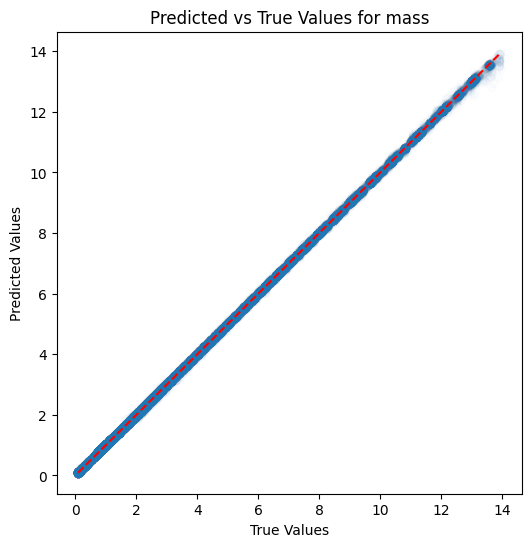

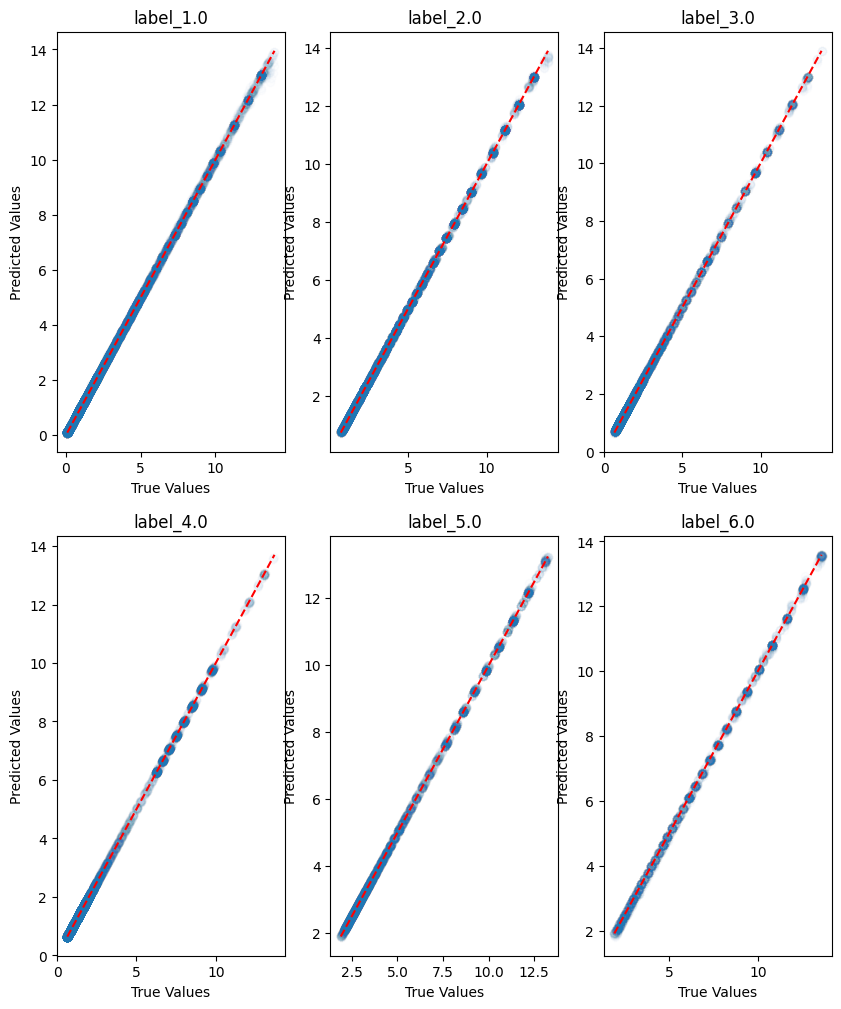

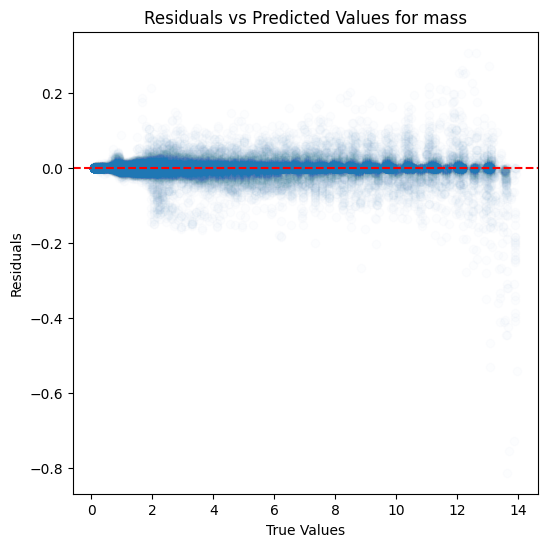

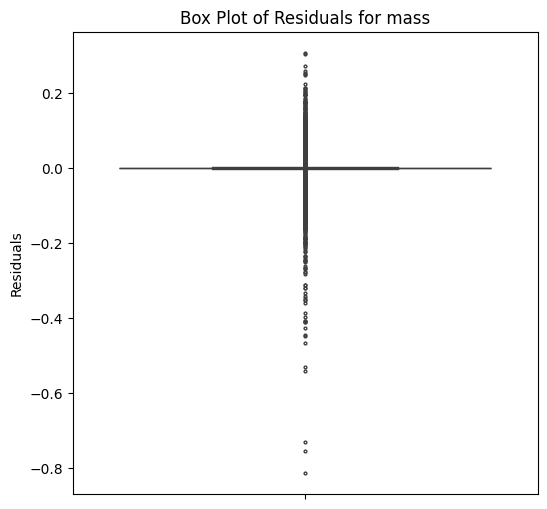

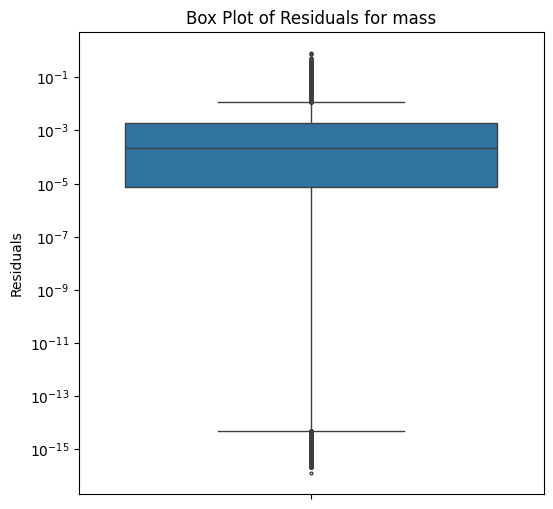

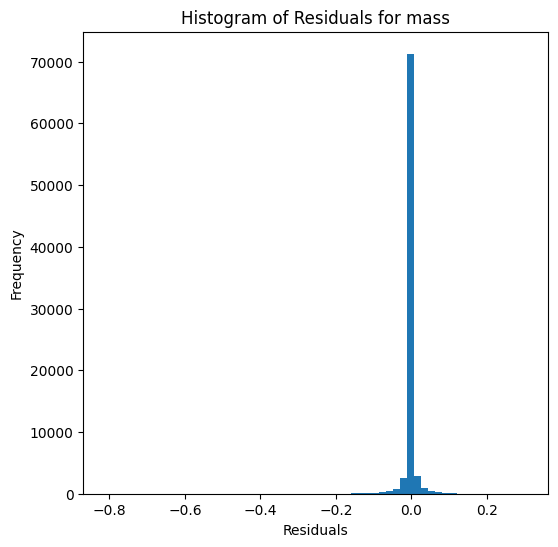

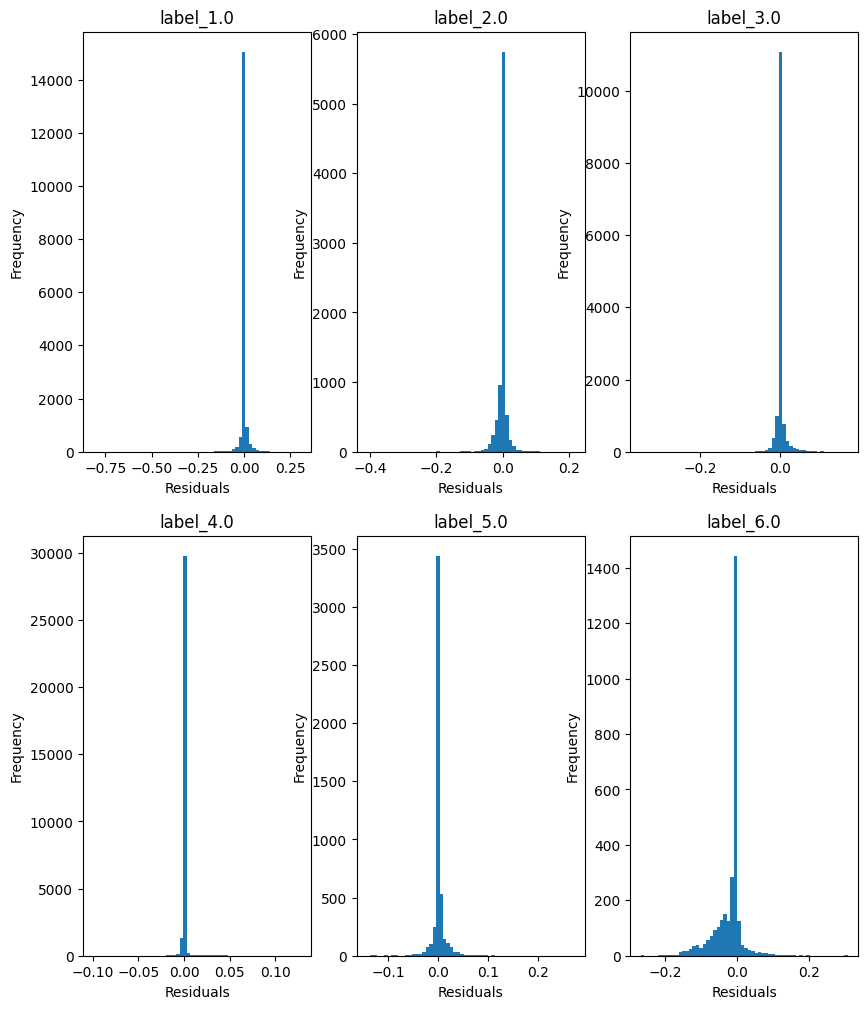

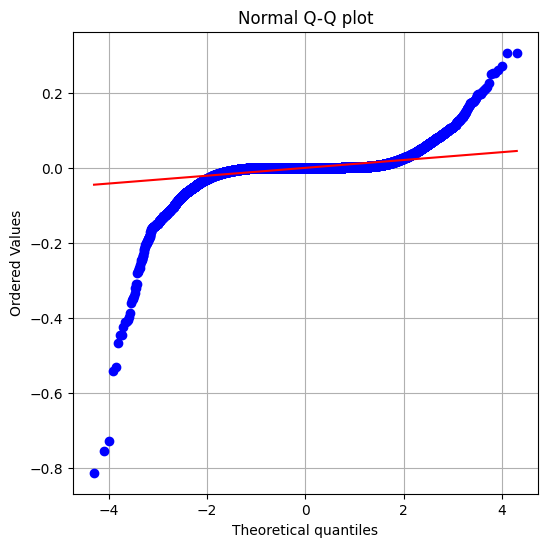

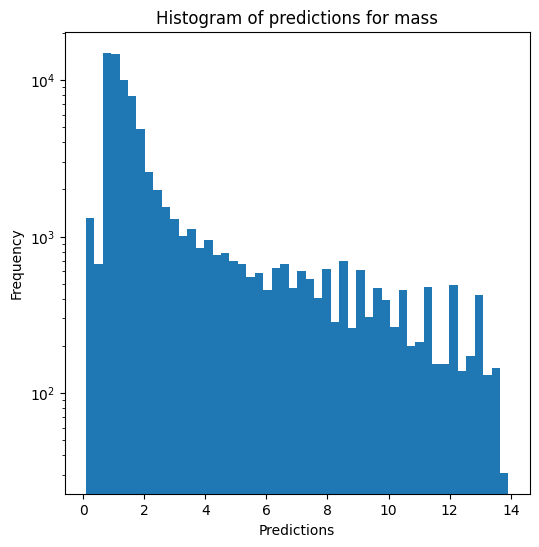

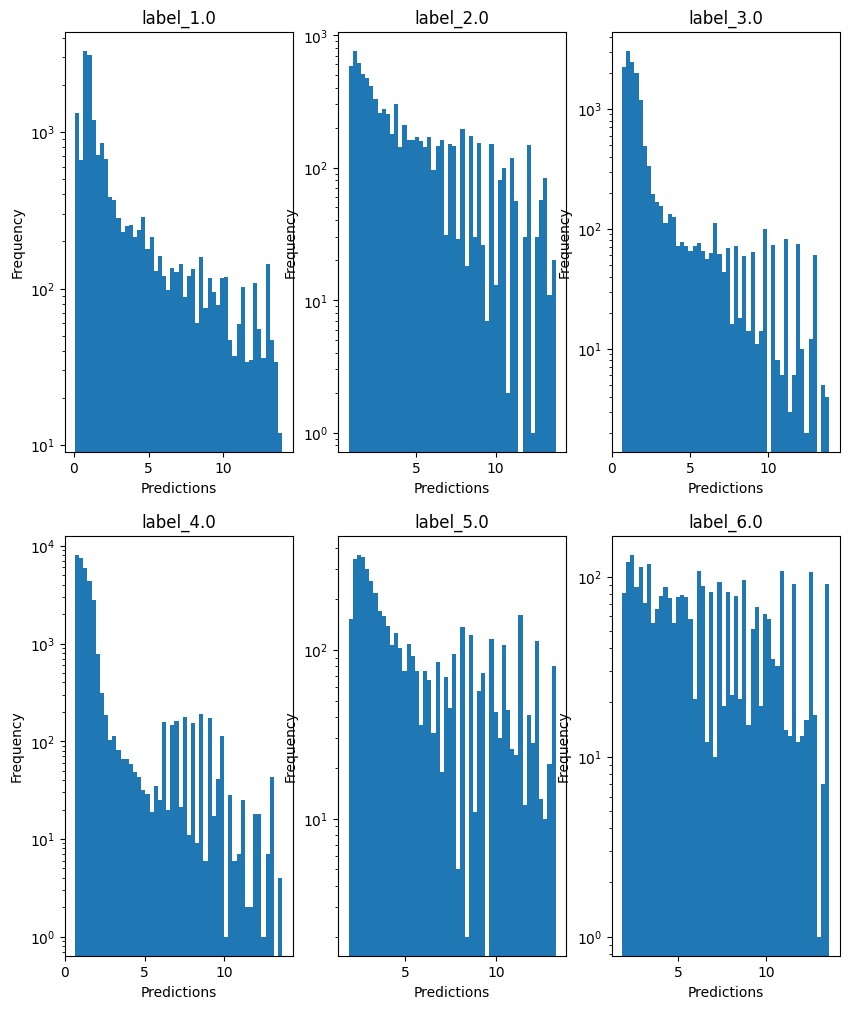

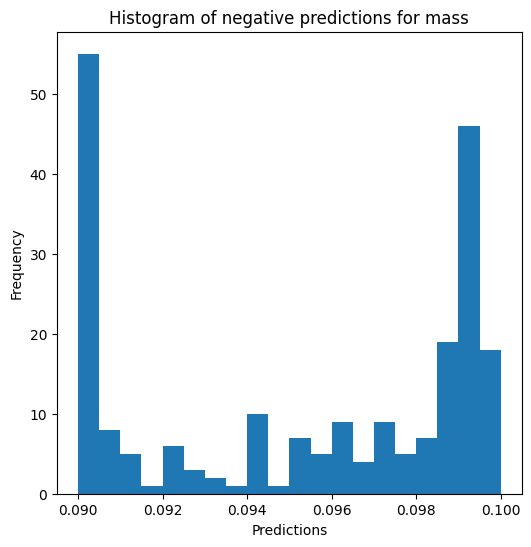


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.9999563372992015
  RMSE :  0.002442979767361863
  MAE :  0.001030336568372148
  MedAE :  0.00023935995017568268
  CORR :  0.9999782748947996
  MAX_ER :  0.04134340376933565
  Percentiles : 
    75th percentile :  0.0009477412371259042
    90th percentile :  0.0028415040198171786
    95th percentile :  0.004730549012796308
    99th percentile :  0.010699921973066996

radius results for the label category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.9998809405378958
  RMSE :  0.005973492958727178
  MAE :  0.002368666733435215
  MedAE :  0.0006011189776981007
  CORR :  0.9999483769959712
  MAX_ER :  0.12145572325947285
  Percentiles : 
    75th percentile :  0.0023098536289826166
    90th percentile :  0.006203159352891607
    95th percentile :  0.010274304137749492
    99th percentile :  0.02375653794399153

radius result

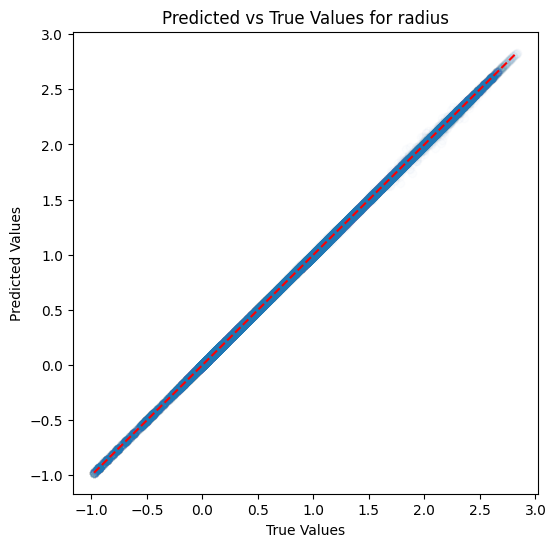

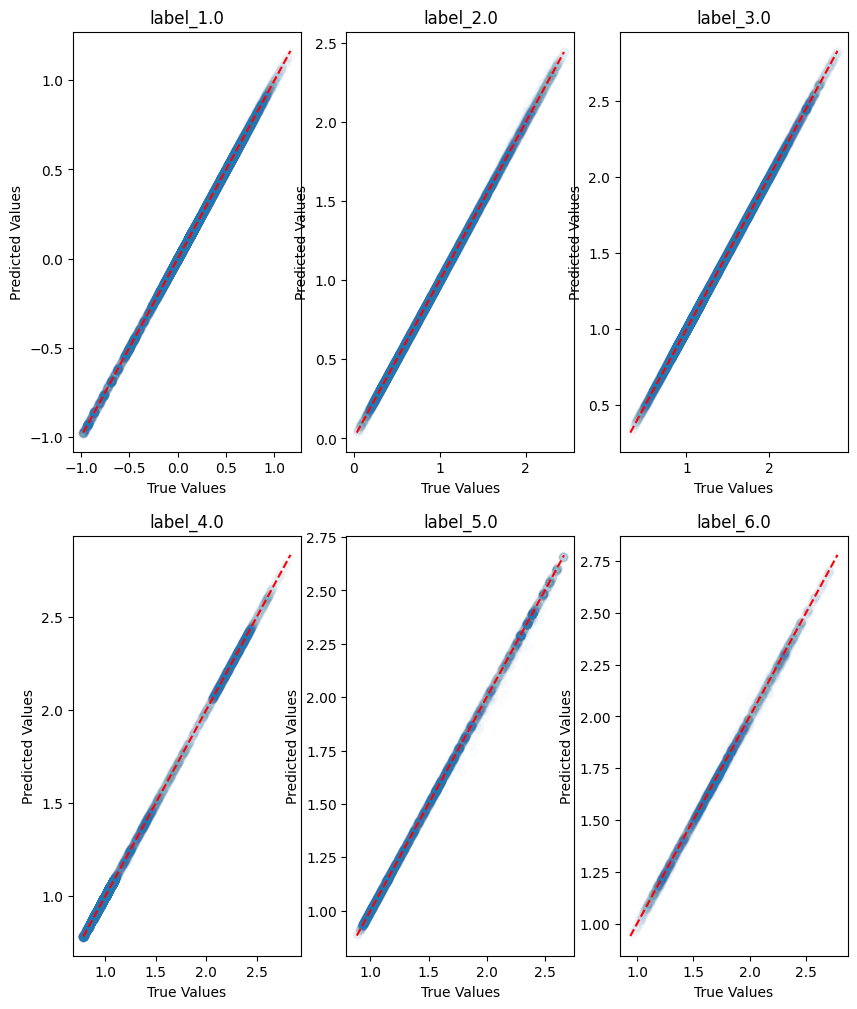

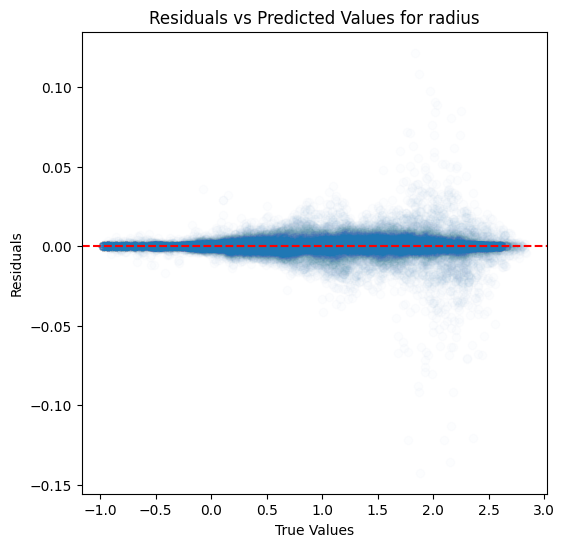

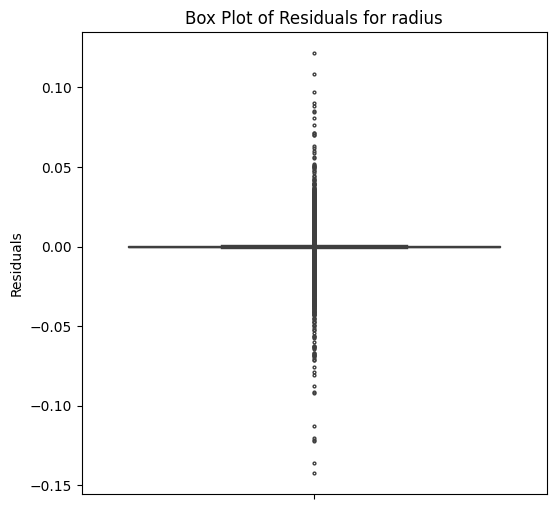

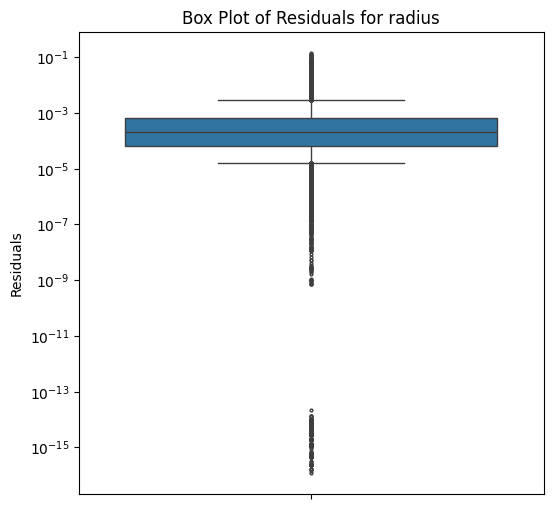

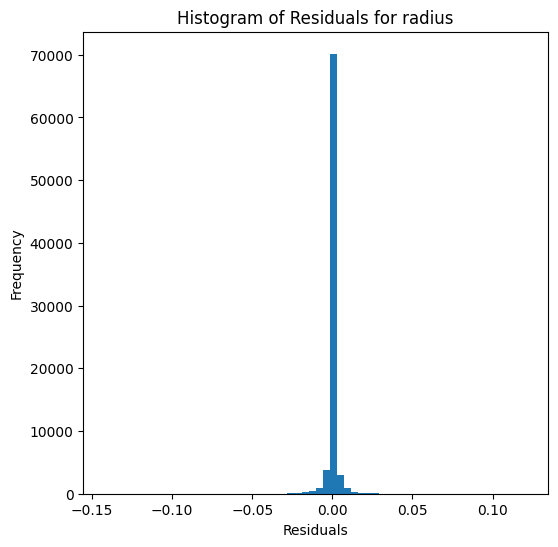

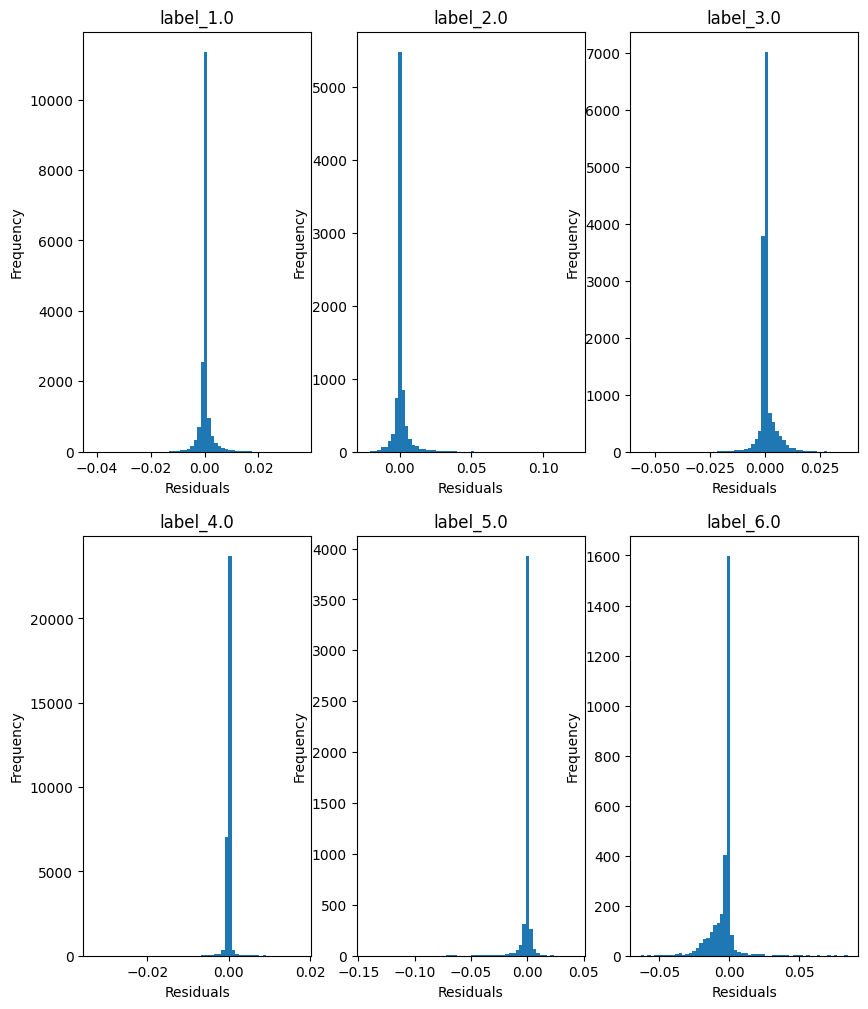

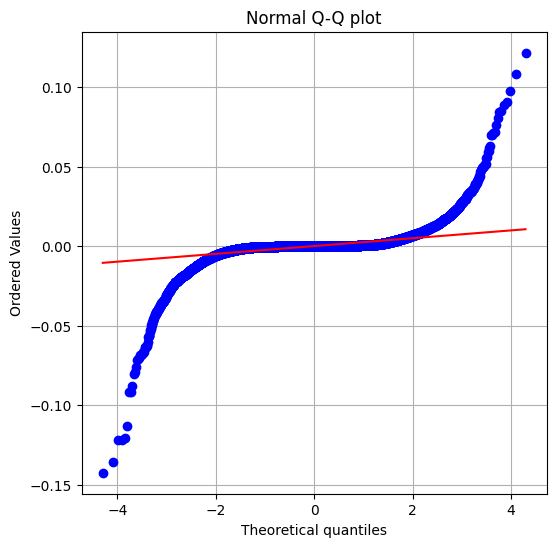

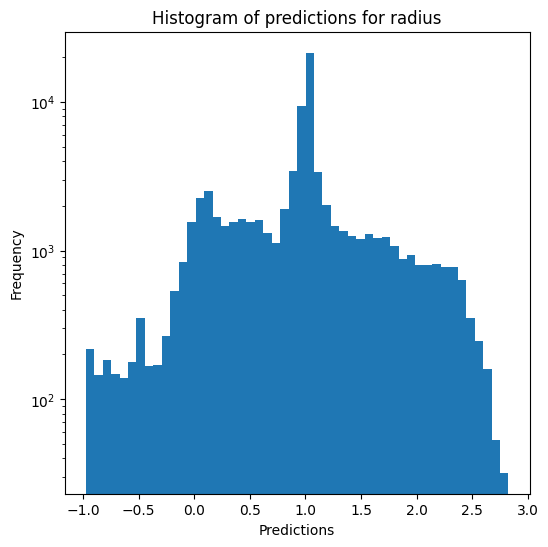

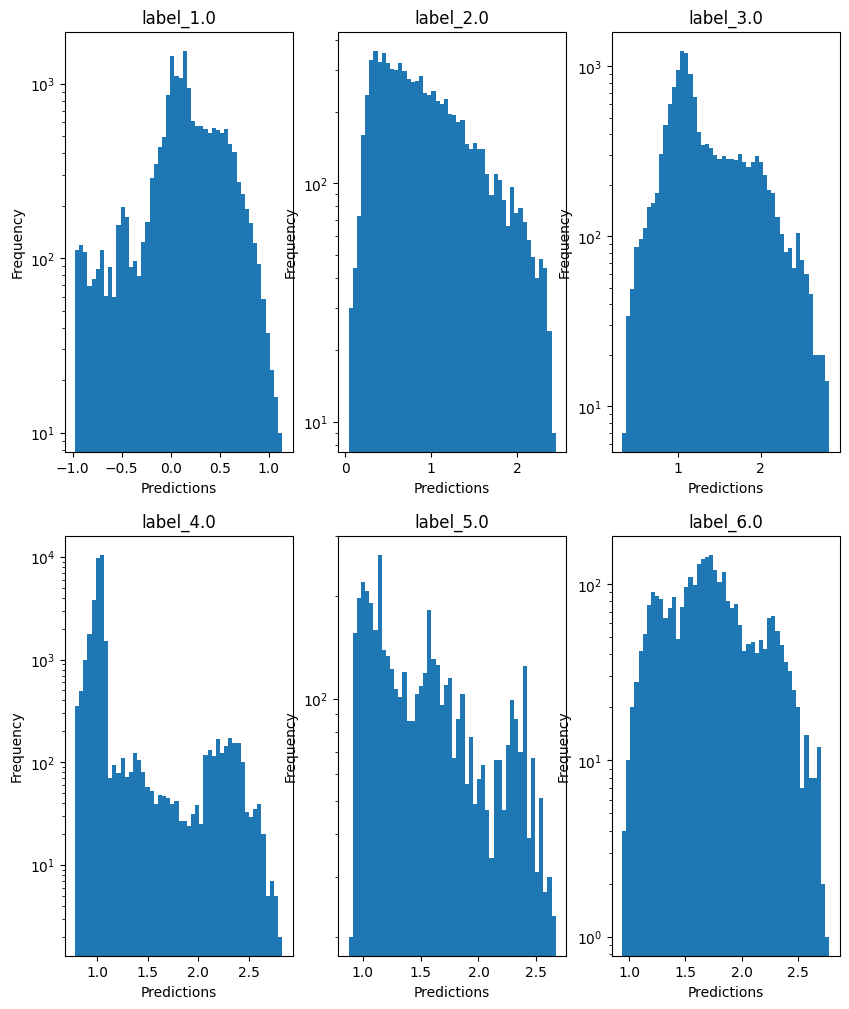

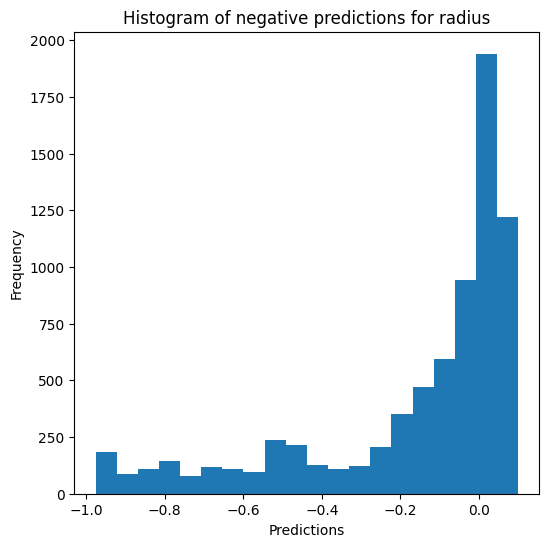

Saving predictions and results...


In [7]:
best_params_RF = {'n_jobs':10, 'n_estimators': 400, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None}

evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(RandomForestRegressor, X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=True, show=True, **best_params_RF)

## KNN

In [11]:
tag = "scale_standard"


scale_standard train data :
Training the model...
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.952
  RVE :  0.999573384004398
  RMSE :  0.06317023991246928
  MAE :  0.0241506501073223
  MedAE :  0.005405095293843698
  CORR :  0.9997894141605348
  MAX_ER :  1.4676574585253501
  Percentiles : 
    75th percentile :  0.02027008957144294
    90th percentile :  0.06332142187222675
    95th percentile :  0.11125393578576635
    99th percentile :  0.2775869473200048

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9986418708792896
  RMSE :  0.12267505280806588
  MAE :  0.05281752734392934
  MedAE :  0.01728673681044679
  CORR :  0.9993790439895776
  MAX_ER :  1.8727553927136587
  Percentiles : 
    75th percentile :  0.05371391908765055
    90th percentile :  0.12897278234328907
    95th percentile :  0.20075861433870393
    99th percentile :  0.6332886250787183

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.902
  R

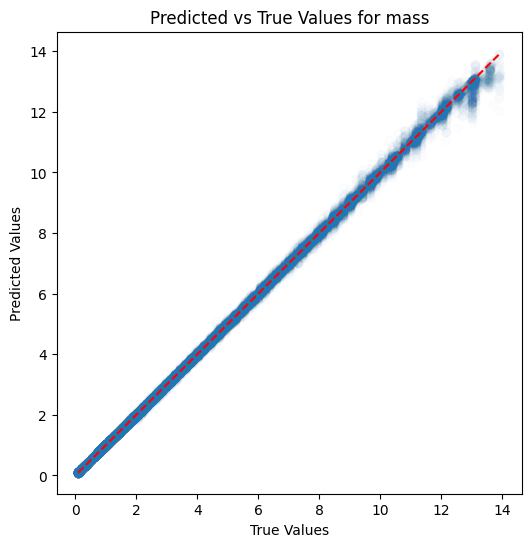

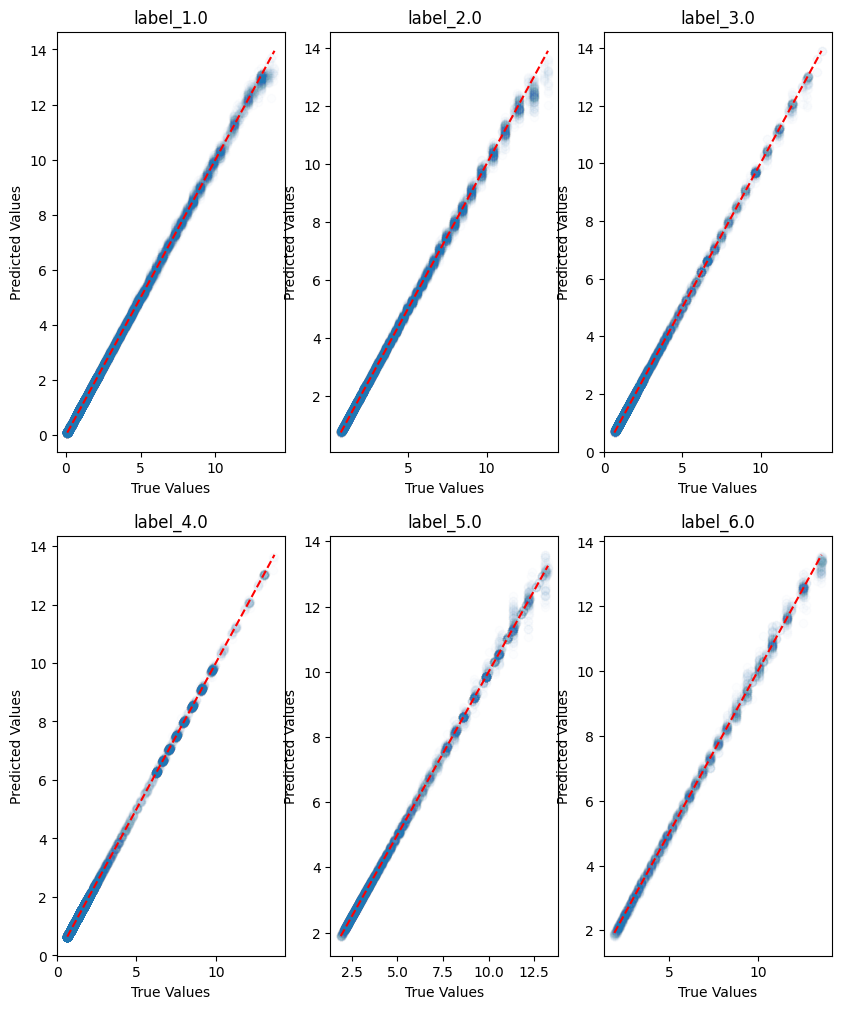

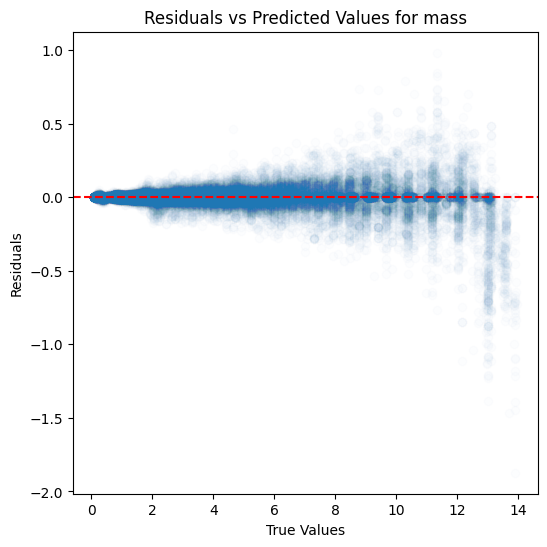

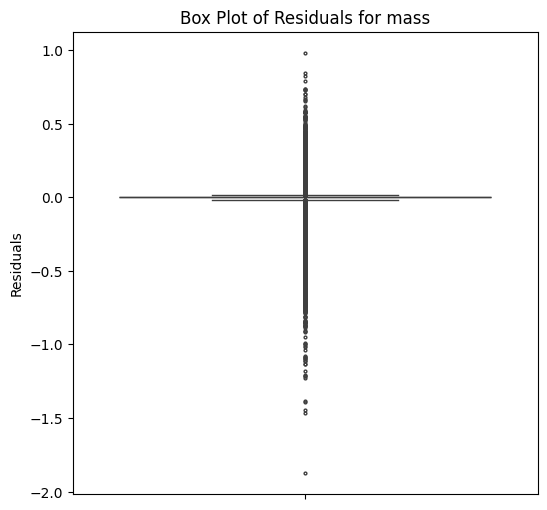

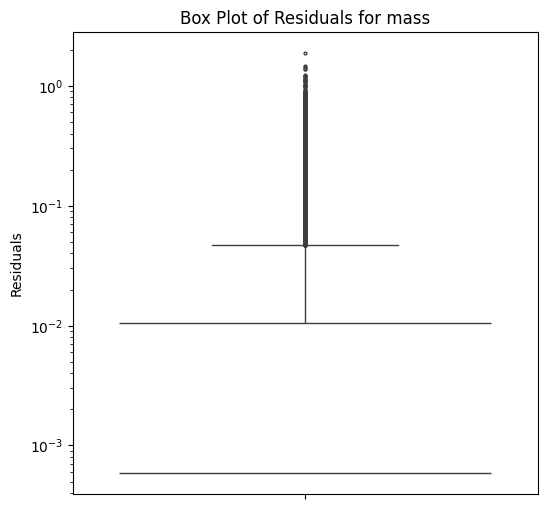

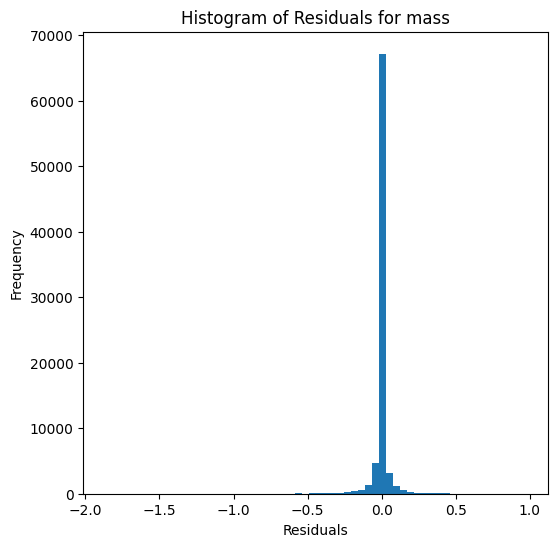

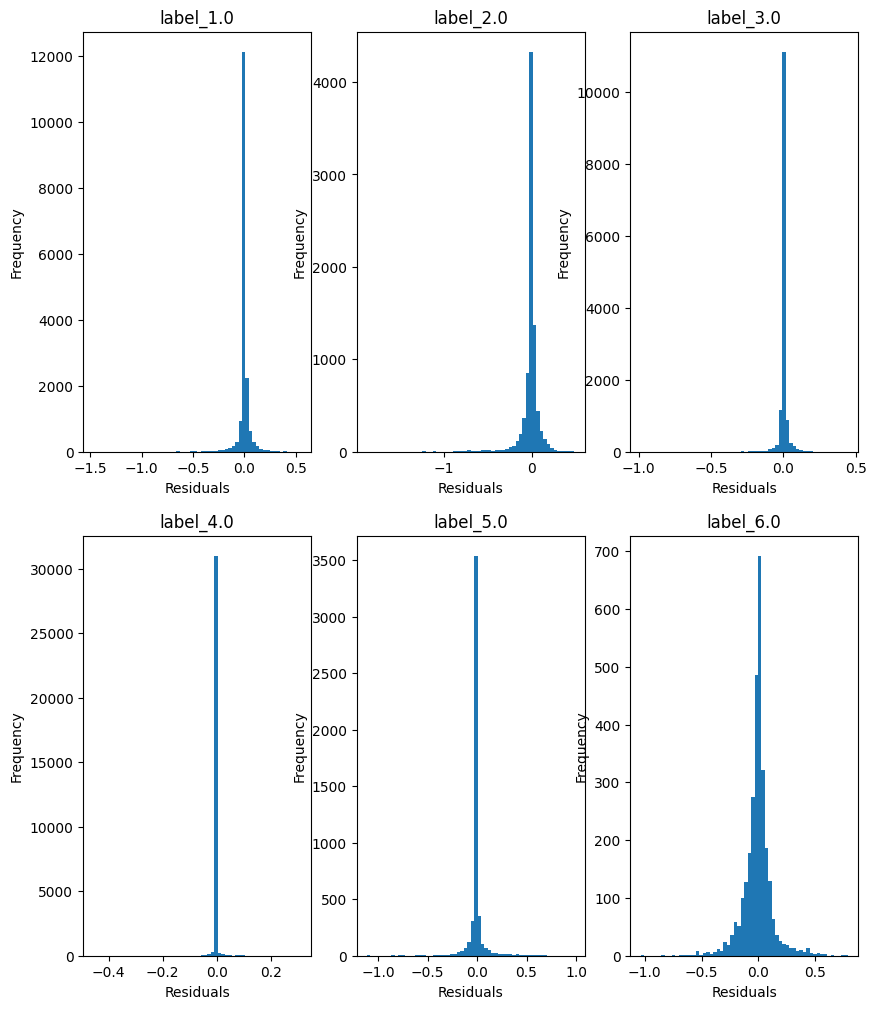

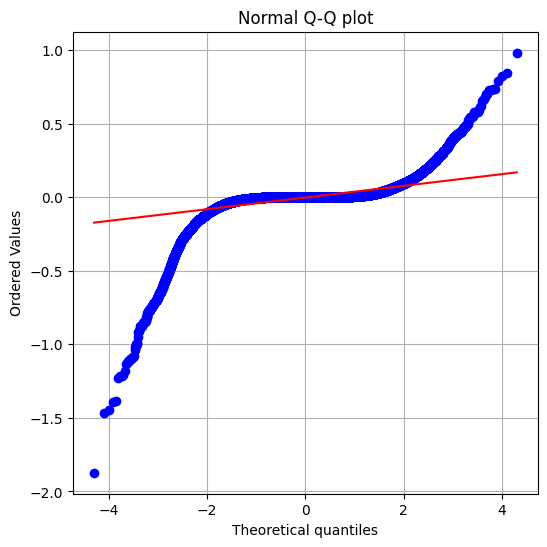

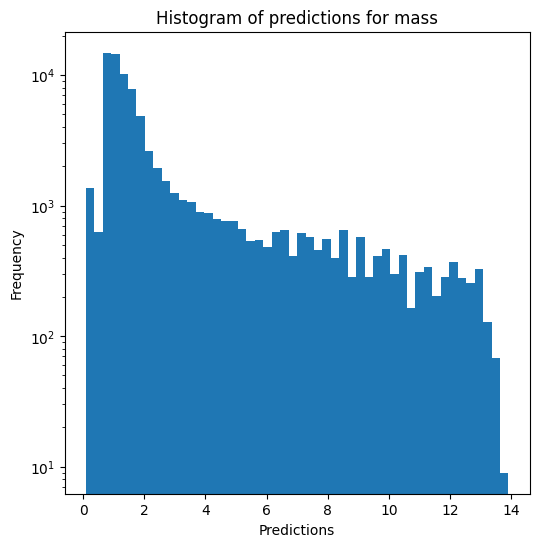

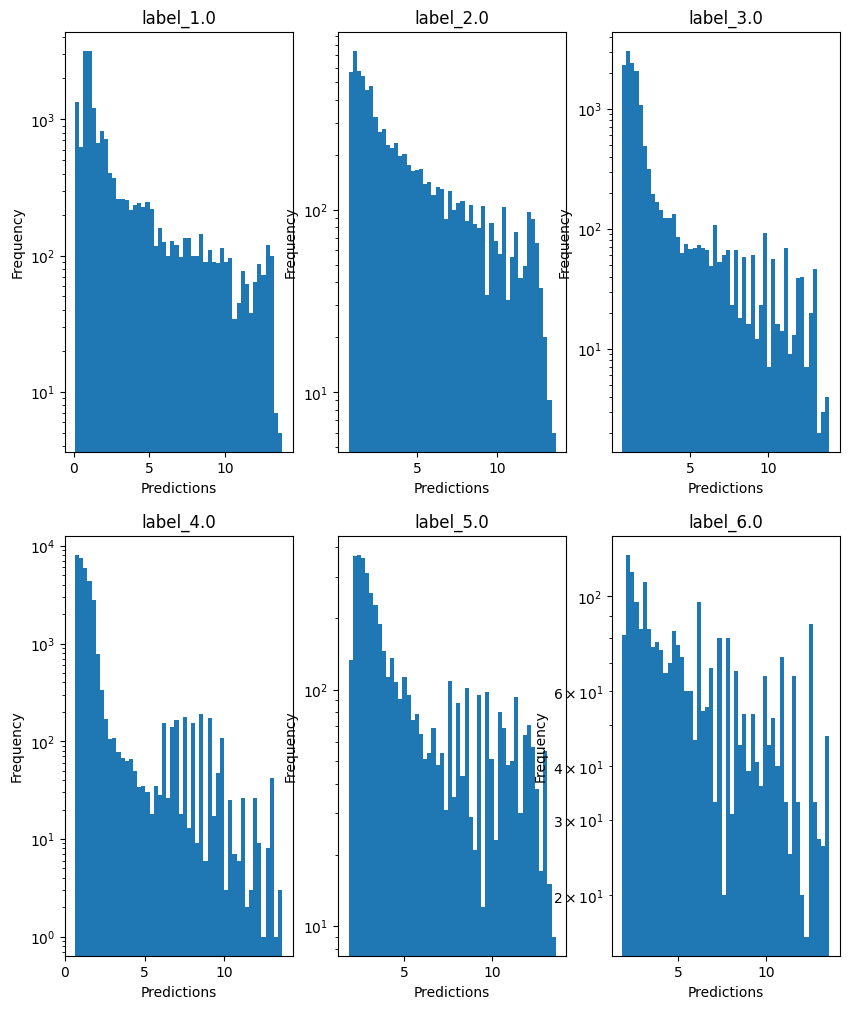

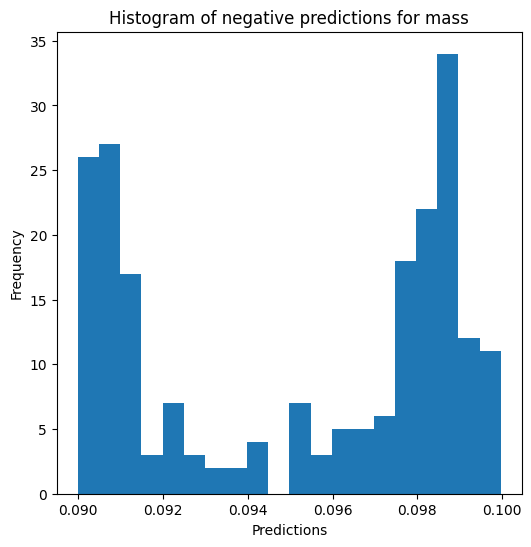


radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.9997152036230126
  RMSE :  0.006236964534788279
  MAE :  0.0039043808618204573
  MedAE :  0.002252725630152417
  CORR :  0.999857687190436
  MAX_ER :  0.05916144593583478
  Percentiles : 
    75th percentile :  0.005359146704873422
    90th percentile :  0.00984623542218215
    95th percentile :  0.013344153129207932
    99th percentile :  0.022525998006588315

radius results for the label category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.9996617329451778
  RMSE :  0.009965671497993621
  MAE :  0.006679181161085448
  MedAE :  0.004730964393629411
  CORR :  0.9998344735789371
  MAX_ER :  0.1371099450281681
  Percentiles : 
    75th percentile :  0.008399974109704014
    90th percentile :  0.01405525272353475
    95th percentile :  0.019259433005552894
    99th percentile :  0.03351483300805976

radius results for the

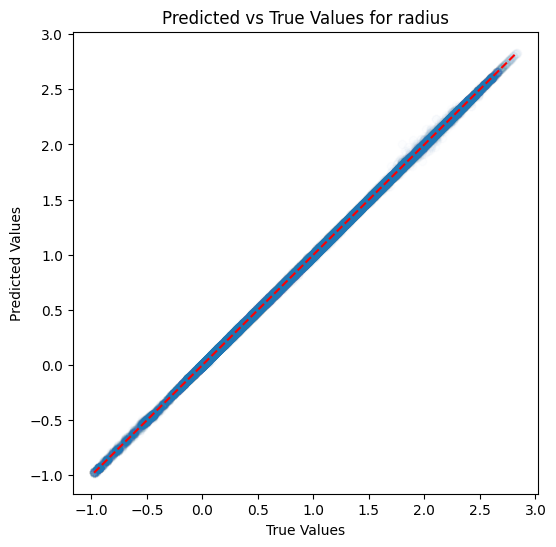

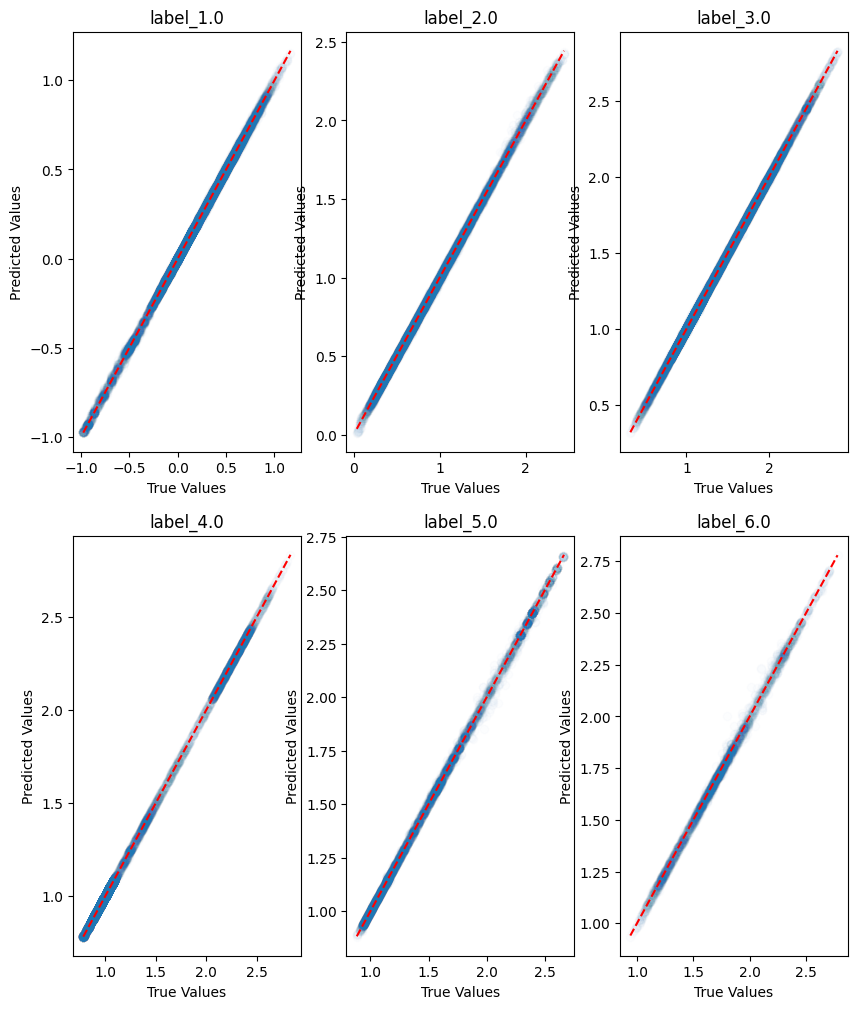

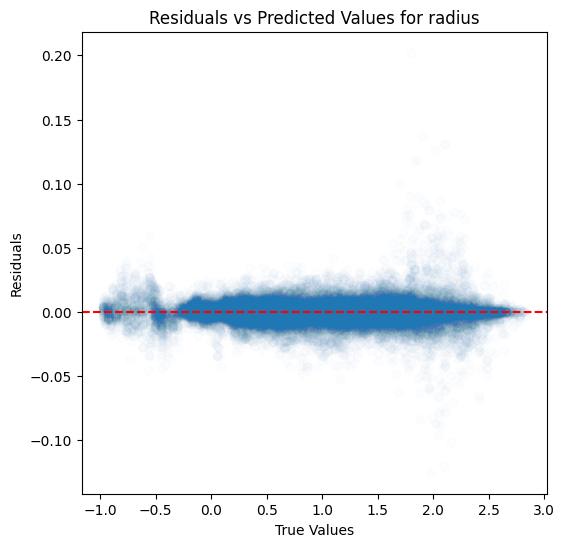

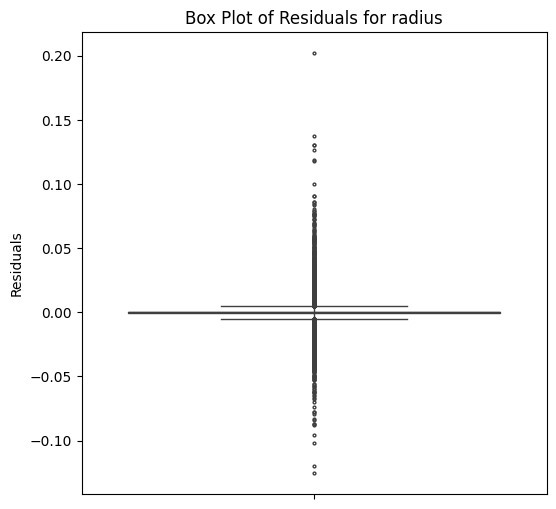

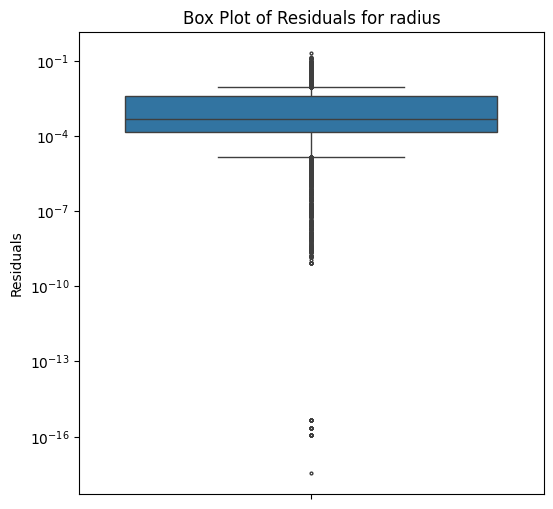

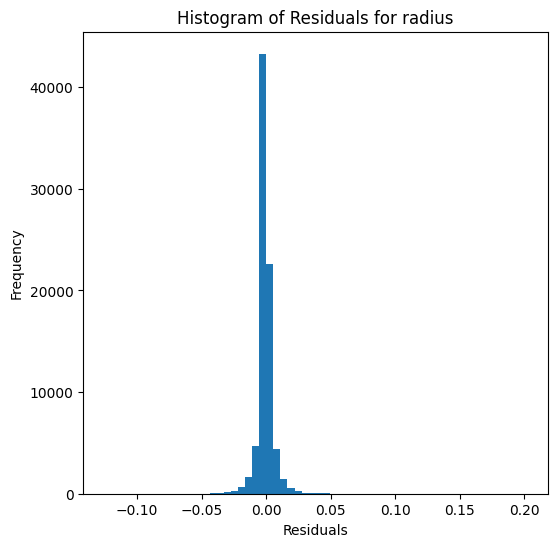

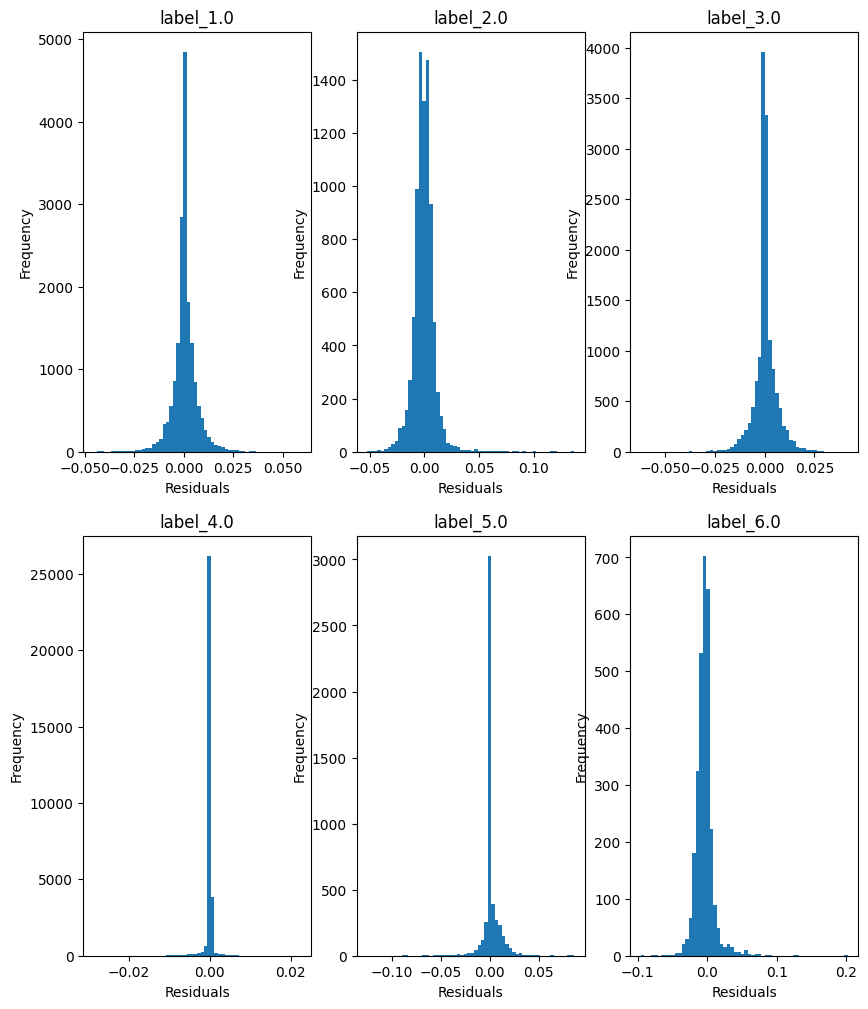

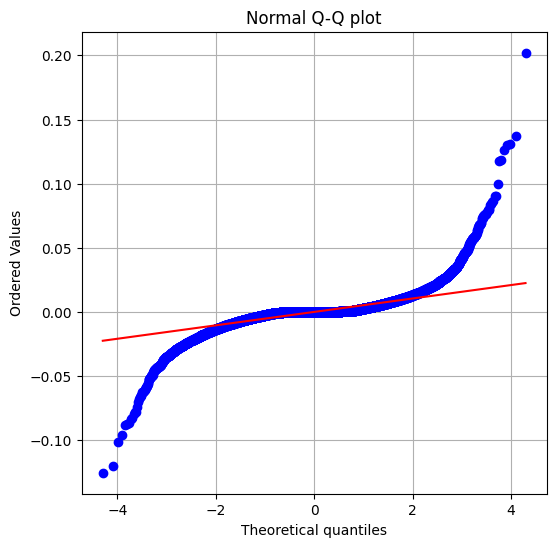

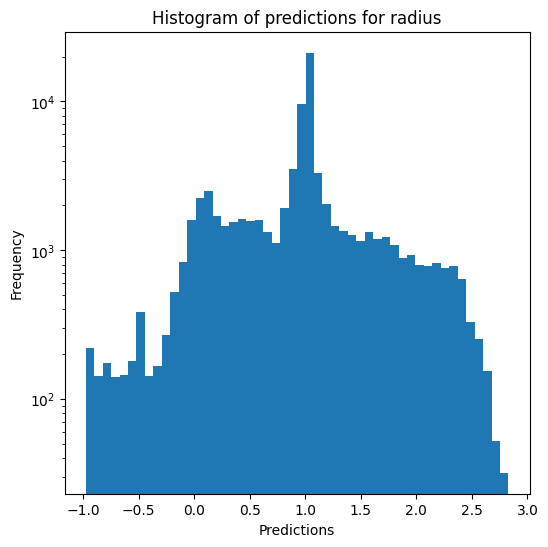

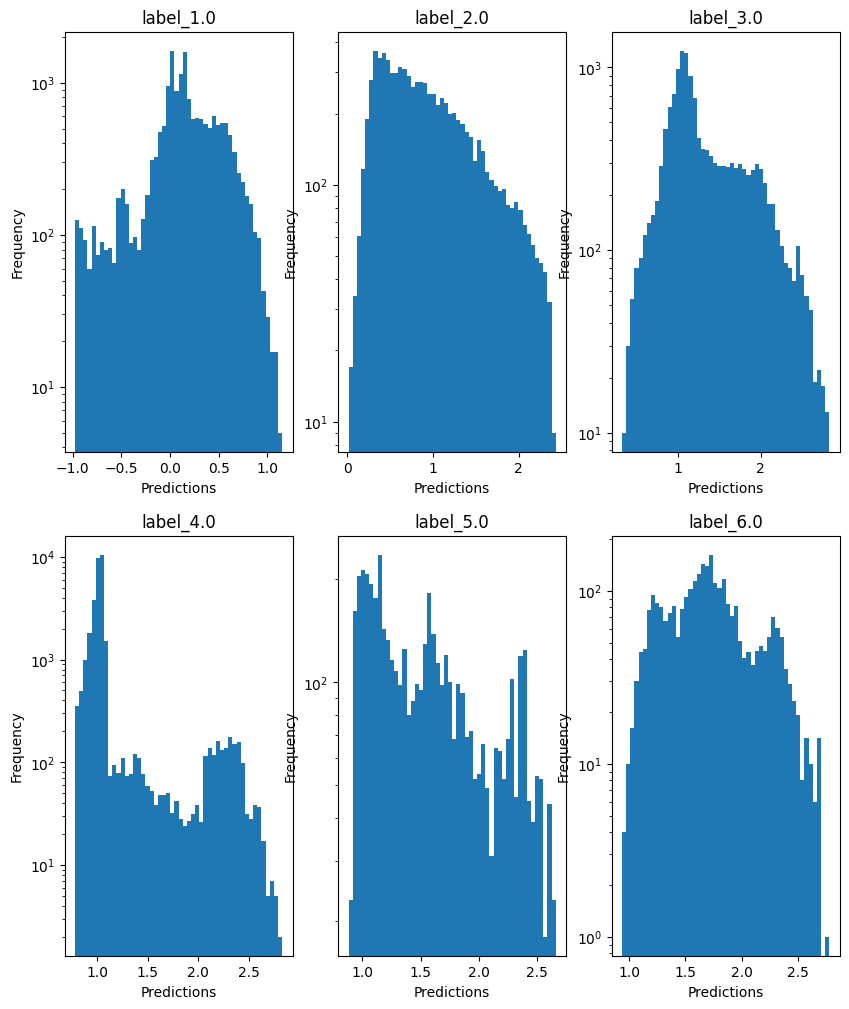

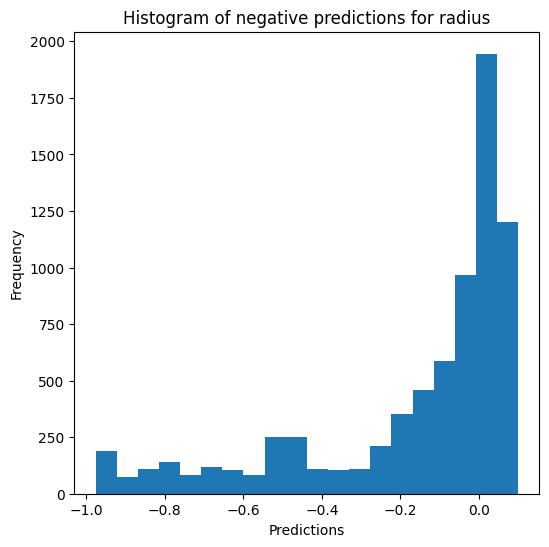

Saving predictions and results...


In [12]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.3, 'weights': 'distance'}

evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(KNeighborsRegressor, X_train_standard, X_ivs_standard, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=True, show=True, **best_params_KNN)

## Decision tree

In [13]:
tag = "scale_quantile"


scale_quantile train data :
Training the model...
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.952
  RVE :  0.9995378987940222
  RMSE :  0.06574487882466071
  MAE :  0.01696233104625173
  MedAE :  1.1102230246251565e-16
  CORR :  0.9997690467142661
  MAX_ER :  1.5089999999999986
  Percentiles : 
    75th percentile :  0.0036000000000000476
    90th percentile :  0.034999999999999906
    95th percentile :  0.09500000000000064
    99th percentile :  0.3175195000000012

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9999260452216291
  RMSE :  0.028408335744082077
  MAE :  0.011198613061797789
  MedAE :  4.440892098500626e-16
  CORR :  0.9999630494544831
  MAX_ER :  0.5443999999999996
  Percentiles : 
    75th percentile :  0.011333333333332973
    90th percentile :  0.03623499999999998
    95th percentile :  0.055333333333333456
    99th percentile :  0.11504666666666713

mass results for the label category with a value of 3.0
  value range :  0.65

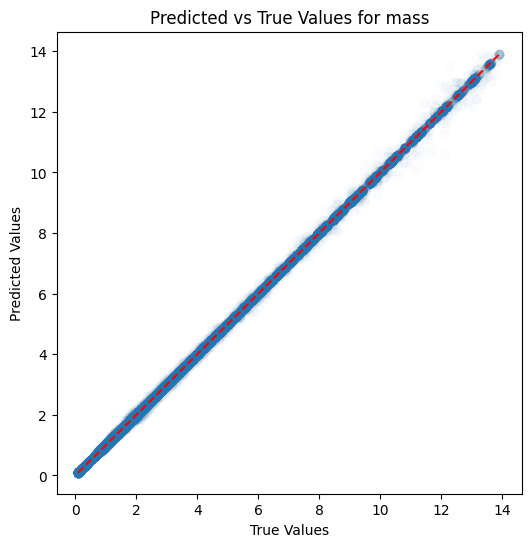

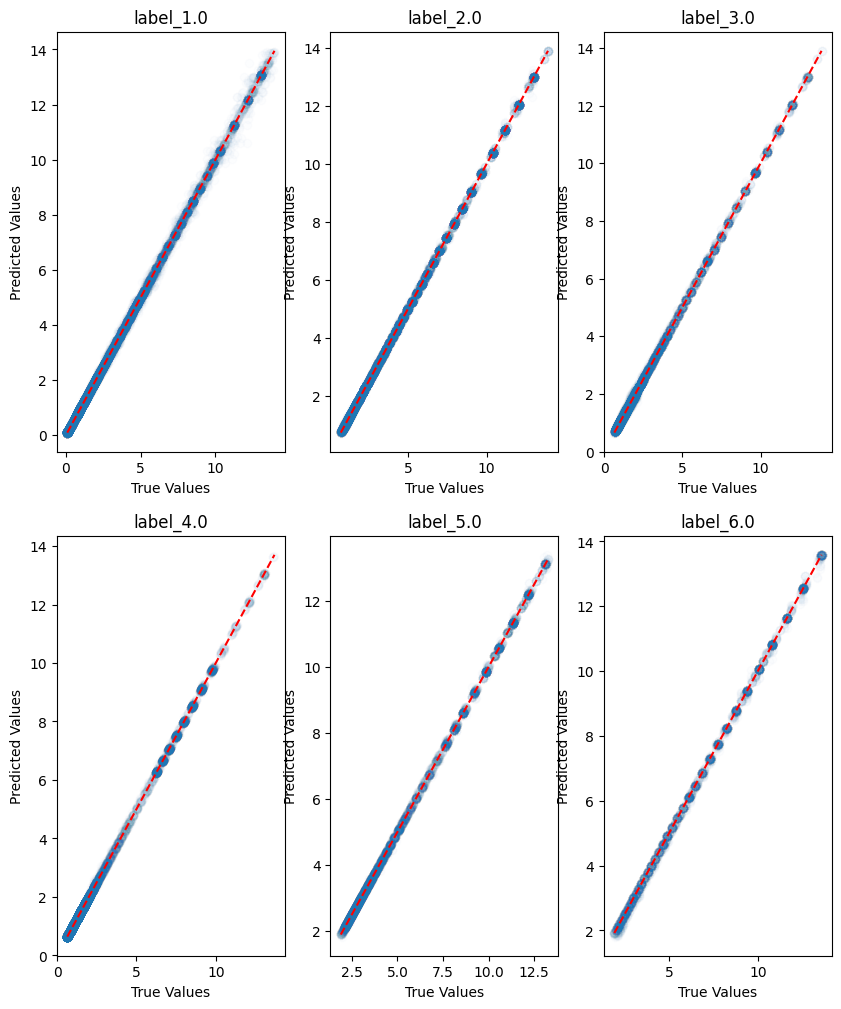

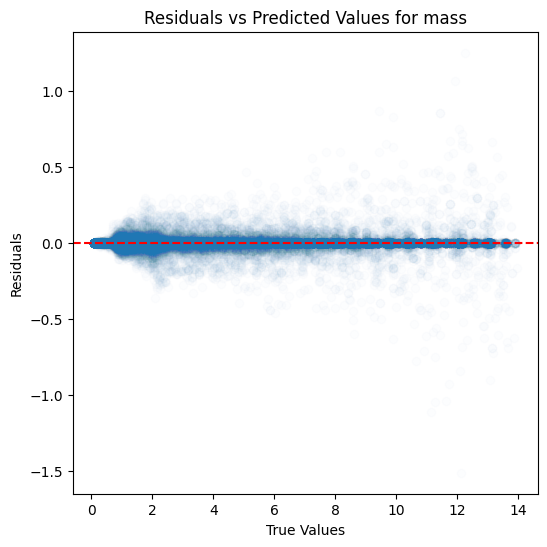

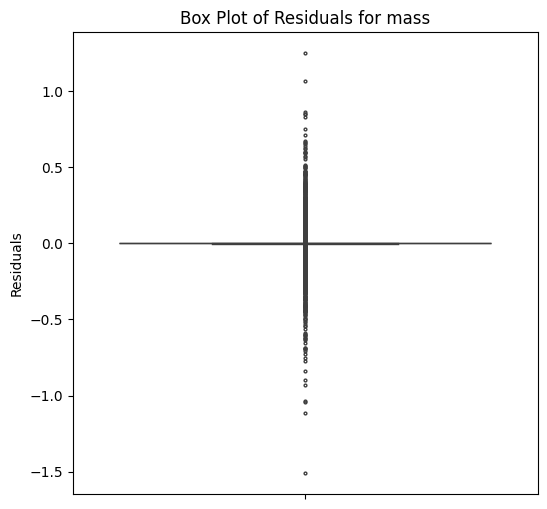

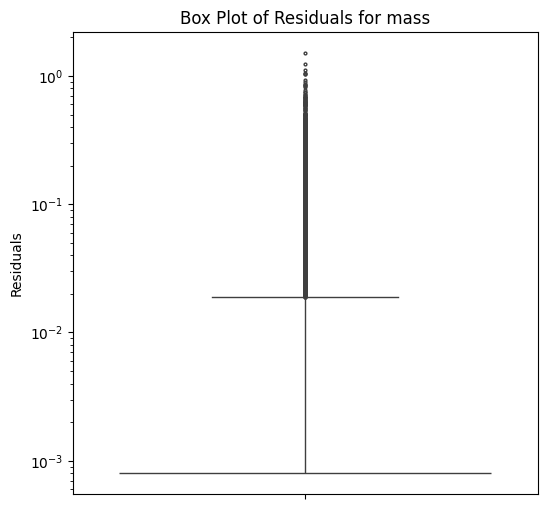

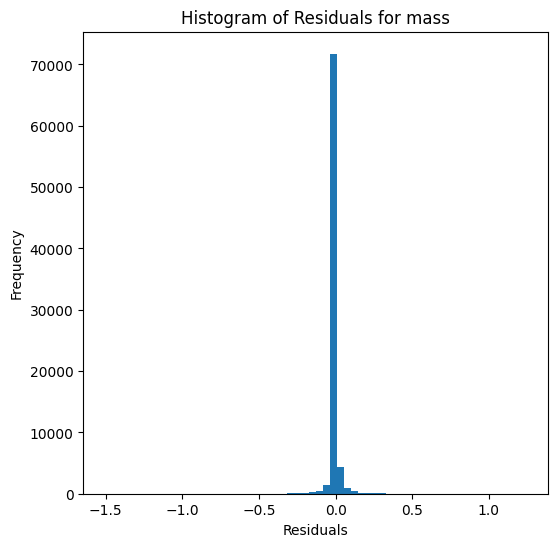

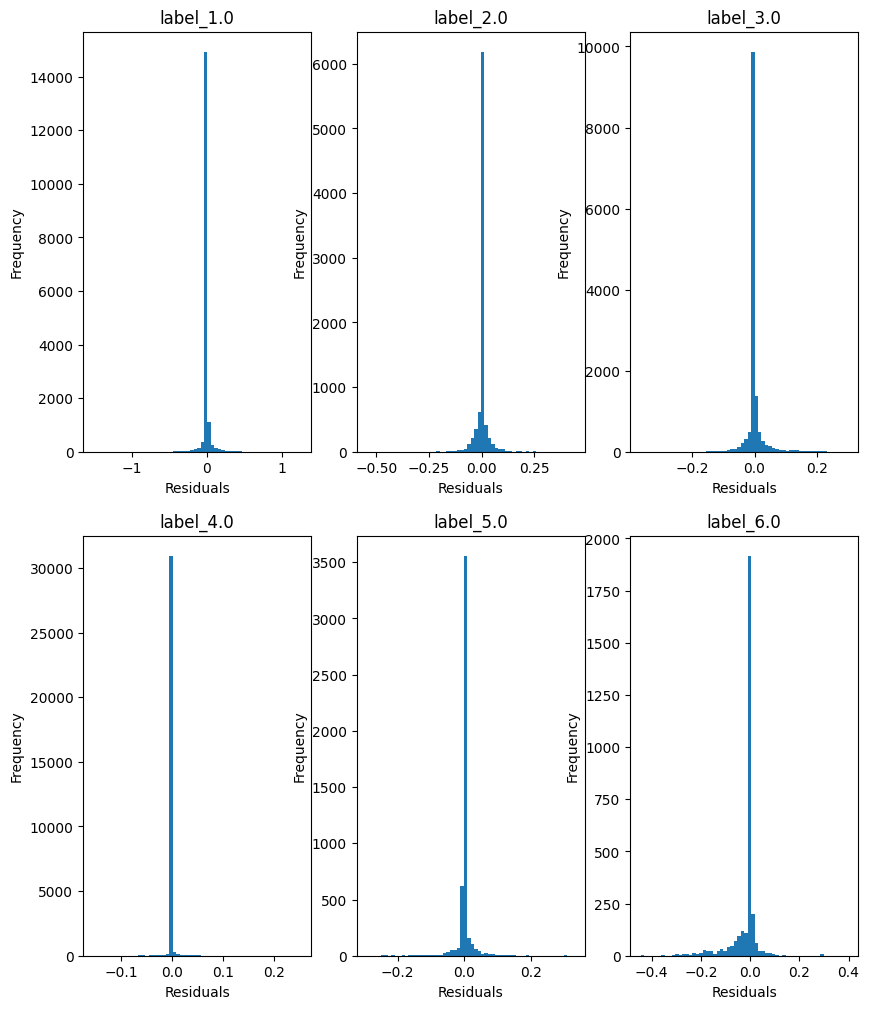

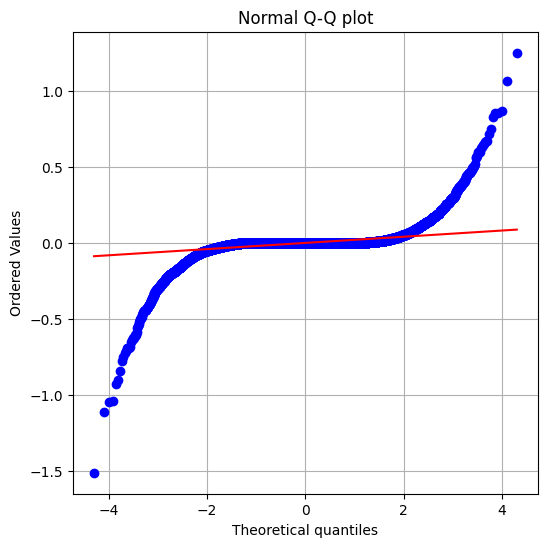

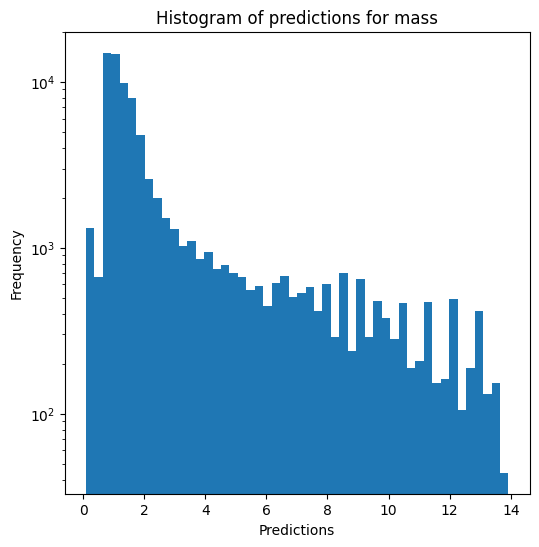

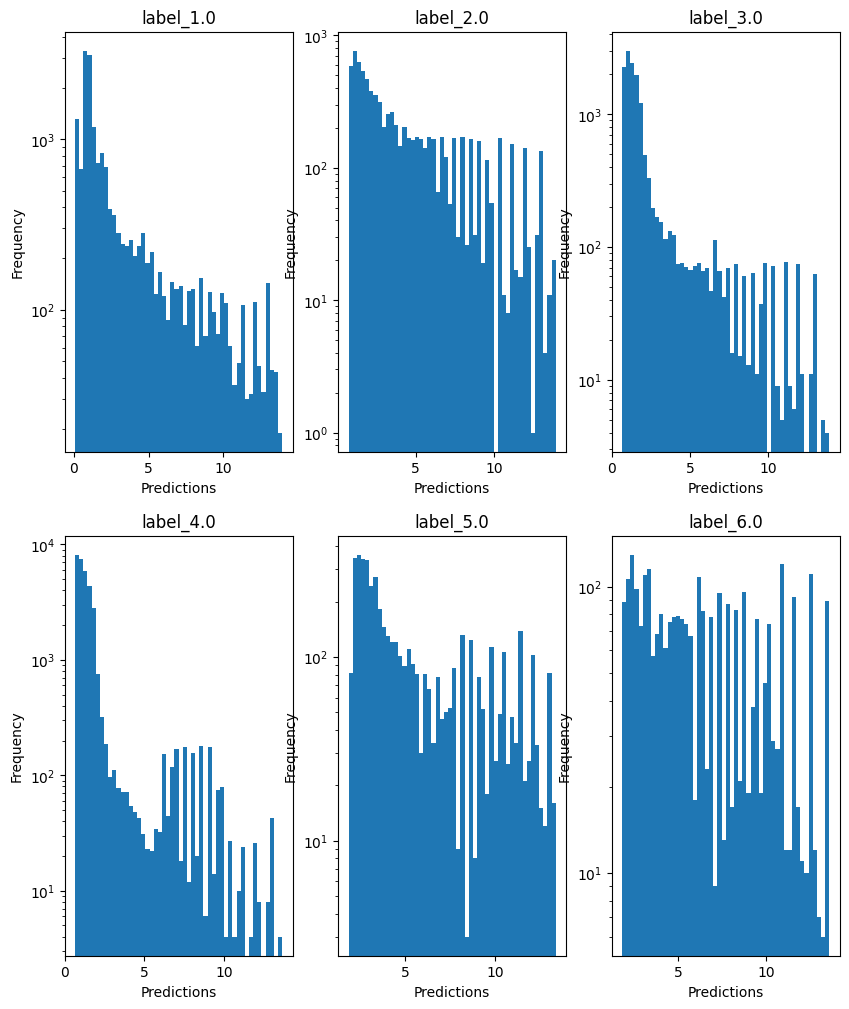

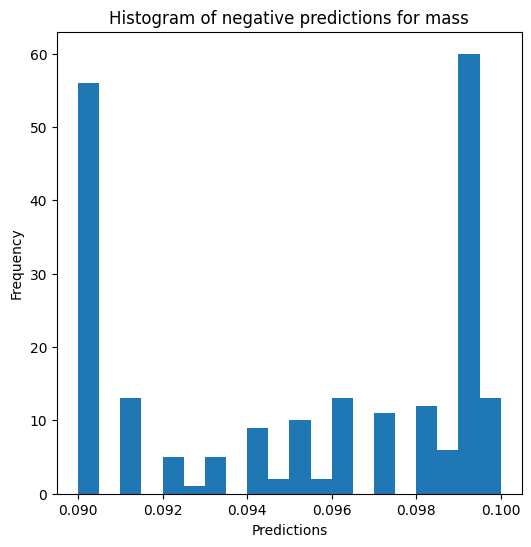

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



radius results for the label category with a value of 1.0
  value range :  -0.9763360818022064 - 1.165244326125311
  RVE :  0.9995217068987323
  RMSE :  0.008059032120282476
  MAE :  0.003282266430929317
  MedAE :  3.3306690738754696e-16
  CORR :  0.9997612252999433
  MAX_ER :  0.12017009169746837
  Percentiles : 
    75th percentile :  0.002988074174590752
    90th percentile :  0.010705751714322068
    95th percentile :  0.017169350129842366
    99th percentile :  0.0349455532626629

radius results for the label category with a value of 2.0
  value range :  0.0366288953621611 - 2.443262987458695
  RVE :  0.9988654168634858
  RMSE :  0.01822886675084354
  MAE :  0.008130456254644987
  MedAE :  0.0005208380716460459
  CORR :  0.9994364513696941
  MAX_ER :  0.23443552657501465
  Percentiles : 
    75th percentile :  0.009274720995321901
    90th percentile :  0.024620690076338308
    95th percentile :  0.038531751183000736
    99th percentile :  0.07691159534359582

radius results for 

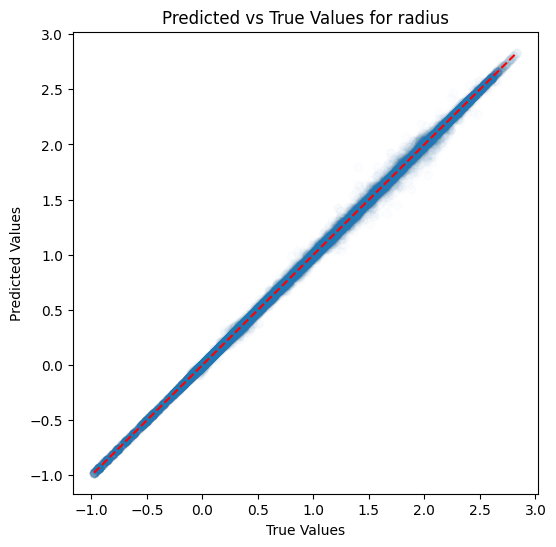

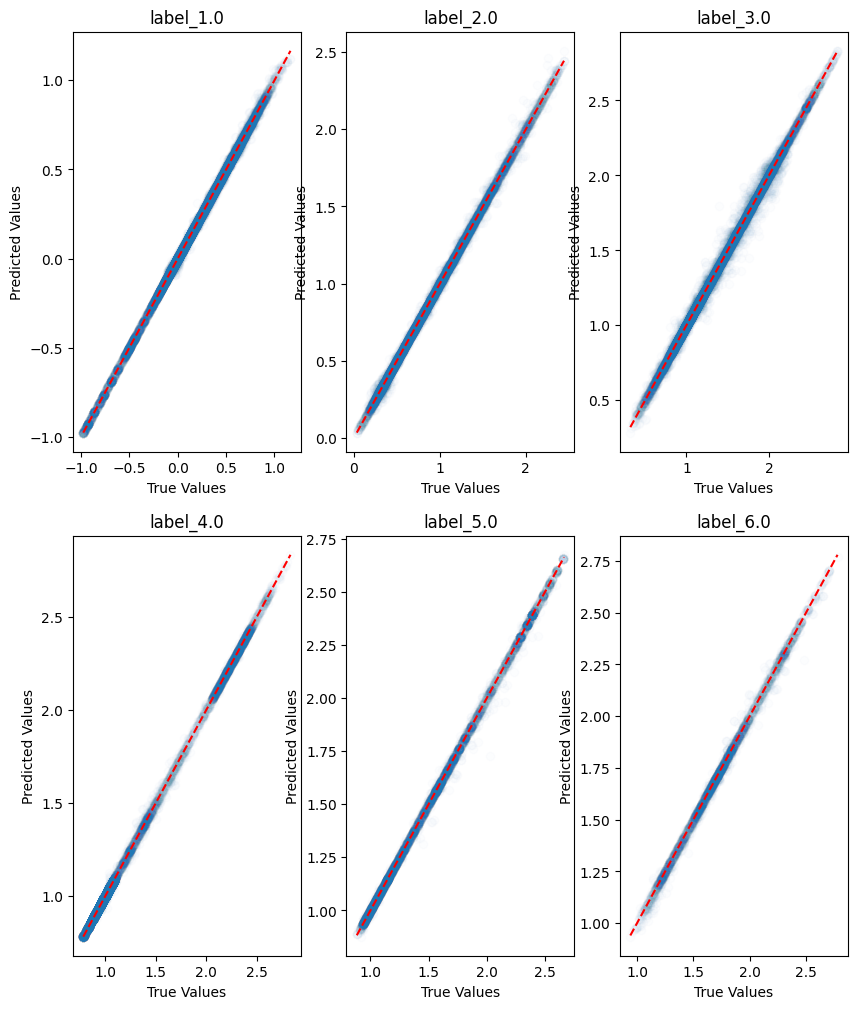

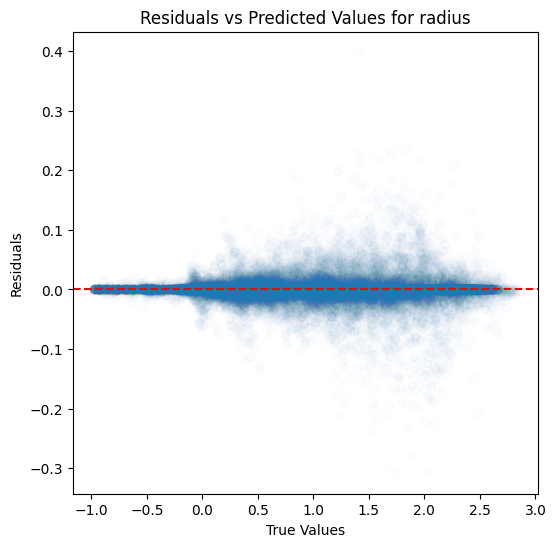

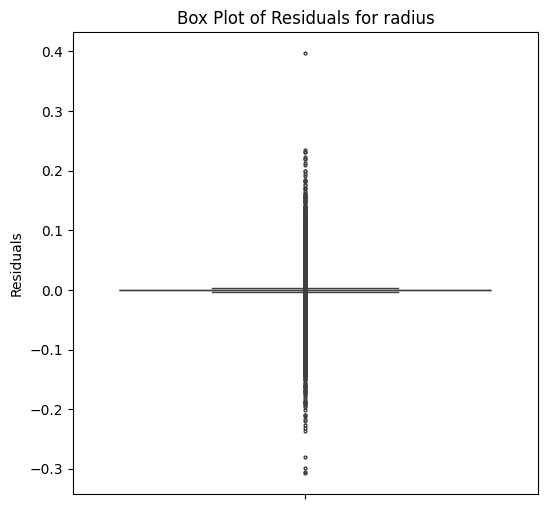

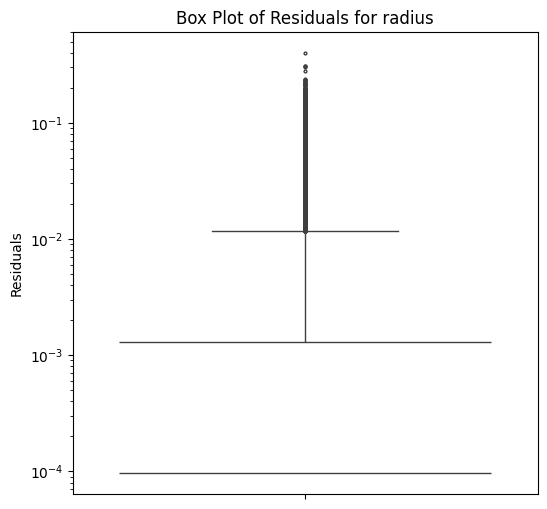

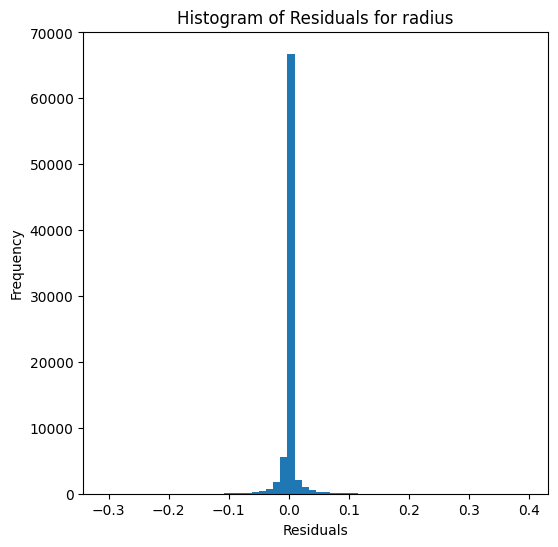

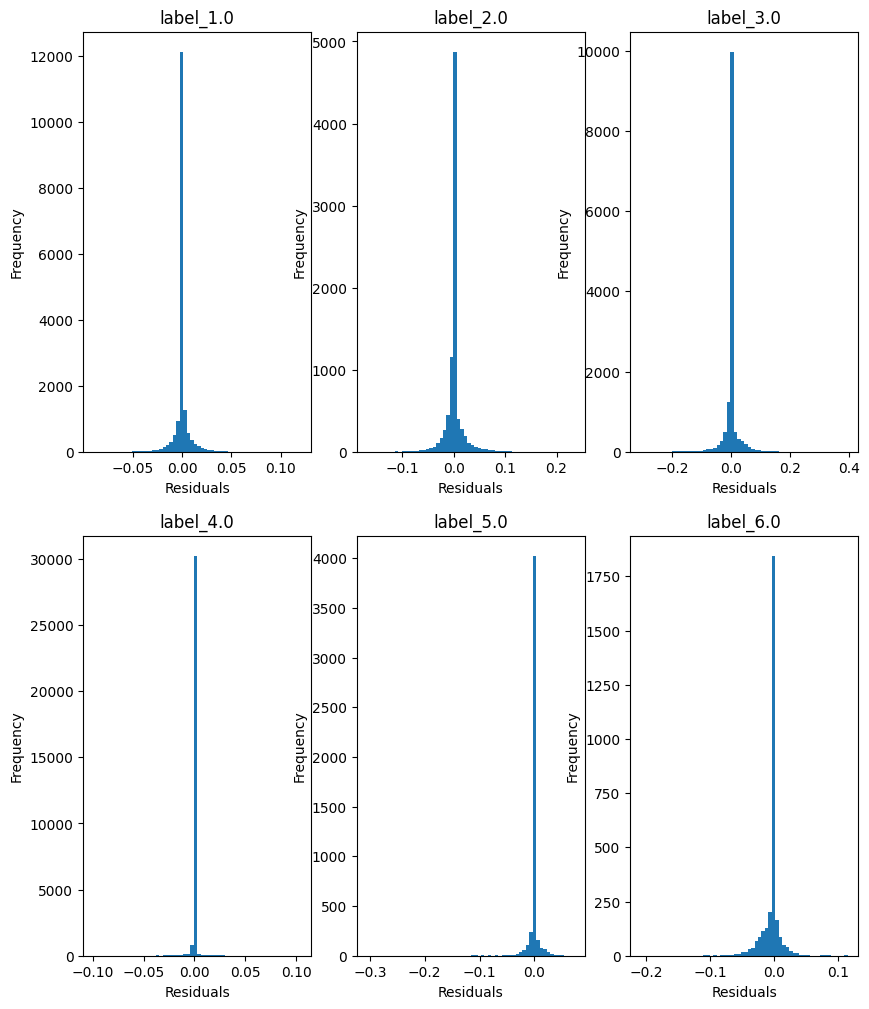

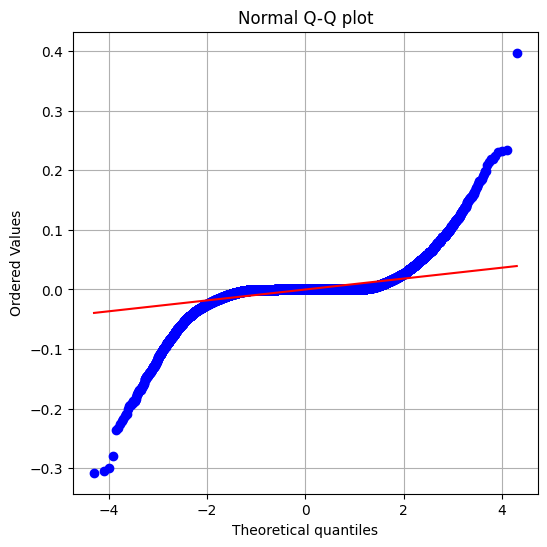

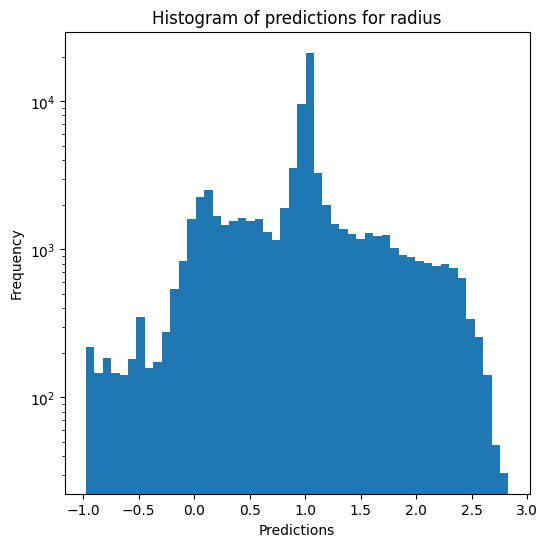

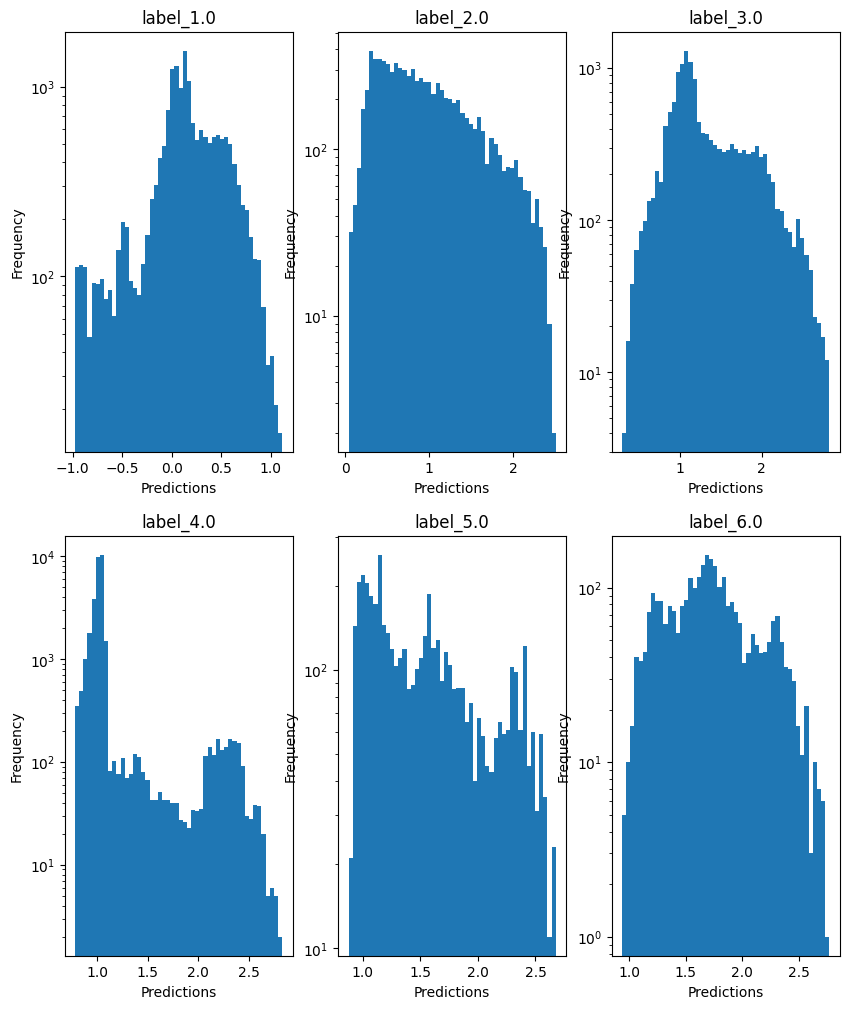

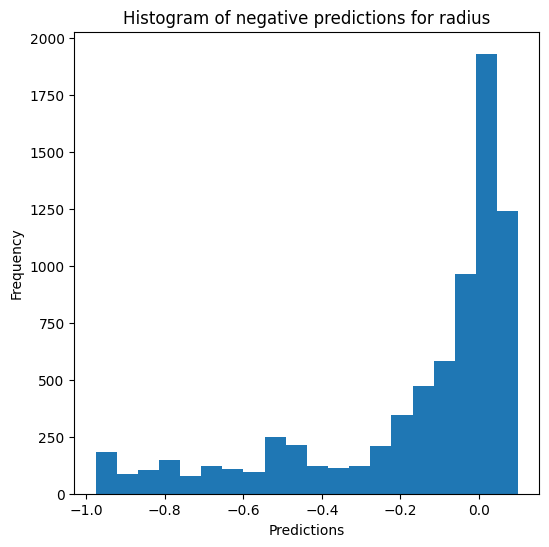

Saving predictions and results...


In [14]:
best_params_DT = {'criterion': 'friedman_mse', 'splitter': "best", 'max_depth': 100, 'min_samples_leaf': 3, 'min_samples_split': 2, 'max_features': None, 'max_leaf_nodes': None}

evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
evaluator.evaluate_ivs_results(DecisionTreeRegressor, X_train_quantile, X_ivs_quantile, y_train, y_ivs, categories_train, categories_ivs, categories_name, 
                               path_to_predictions, tag, override=True, use_preds=False, save=True, show=True, **best_params_DT)

# Training the final models

In [15]:
X = np.append(X_train, X_ivs, 0)
X_standard = np.append(X_train_standard, X_ivs_standard, 0)
X_quantile = np.append(X_train_quantile, X_ivs_quantile, 0)
y = np.append(y_train, y_ivs, 0)

print(X.shape)
print(X_standard.shape)
print(X_quantile.shape)
print(y.shape)

(321696, 4)
(321696, 4)
(321696, 4)
(321696, 2)


## Random forest

### Final model with fine-tuned parameters

In [10]:
best_params_RF = {'n_jobs':10, 'n_estimators': 400, 'criterion': 'squared_error', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None}

mdl = RandomForestRegressor(**best_params_RF)
mdl.fit(X, y)

,n_estimators,400
,criterion,'squared_error'
,max_depth,100
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "RF_compress_0.pkl", compress=0)
# 7.3 GB, 1.82 GB après zip
# 11.8 secondes pour créé le fichier

['../../../../../../model/final_models/Model_A_partial_PARSEC_RF_compress_0.pkl']

In [ ]:
joblib.dump(mdl, pre_path + path_to_models + 'test_RF.pkl.z')
# 1.92 GB
# 1 minutes 30 pour créé le fichier

['../../../../../../model/final_models/test_Model_A_partial_PARSEC_RF.pkl.z']

In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "RF_compress_3.pkl", compress=3)
# 1.92 GB
# 1 minutes 30 pour créé le fichier

['../../../../../../model/final_models/Model_A_partial_PARSEC_RF_compress_3.pkl']

## KNN

In [19]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.3, 'weights': 'distance'}

mdl = KNeighborsRegressor(**best_params_KNN)
mdl.fit(X_standard, y)

,n_neighbors,5
,weights,'distance'
,algorithm,'kd_tree'
,leaf_size,100
,p,1.3
,metric,'minkowski'
,metric_params,None
,n_jobs,10


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "KNN_compress_0.pkl", compress=0)
# 0.0 secondes
# 28 MB

['../../../../../../model/final_models/Model_A_partial/PARSEC/KNN_compress_0.pkl']

## Decision tree

In [21]:
best_params_DT = {'criterion': 'friedman_mse', 'splitter': "best", 'max_depth': 100, 'min_samples_leaf': 3, 'min_samples_split': 2, 'max_features': None, 'max_leaf_nodes': None}

mdl = DecisionTreeRegressor(**best_params_DT)
mdl.fit(X_quantile, y)

,criterion,'friedman_mse'
,splitter,'best'
,max_depth,100
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
joblib.dump(mdl, pre_path + path_to_models + "DT_compress_0.pkl", compress=0)
# 0.0 secondes
# 10 MB

['../../../../../../model/final_models/Model_A_partial/PARSEC/DT_compress_0.pkl']